In [6]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import gray2rgb
from skimage import io, color


# Show the figures / plots inside the notebook
%matplotlib inline
from skimage.color import rgb2gray

def show_images(images,titles=None):
    #This function is used to show image(s) with titles by sending an array of images and an array of associated titles.
    # images[0] will be drawn with the title titles[0] if exists
    # You aren't required to understand this function, use it as-is.
    n_ims = len(images)
    if titles is None: titles = ['(%d)' % i for i in range(1,n_ims + 1)]
    fig = plt.figure()
    n = 1
    for image,title in zip(images,titles):
        a = fig.add_subplot(1,n_ims,n)
        if image.ndim == 2: 
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
        n += 1
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_ims)
    plt.show()


In [7]:
def color_correction(img):
    b = np.copy(img[:,:,0])
    g = np.copy(img[:,:,1])
    r = np.copy(img[:,:,2])
    
    mean_r, mean_g, mean_b = np.mean(r), np.mean(g), np.mean(b)
    mean_gray = (mean_r + mean_g + mean_b) / 3
    
    scale_r = mean_gray / mean_r
    scale_g = mean_gray / mean_g
    scale_b = mean_gray / mean_b
    
    r *= scale_r
    g *= scale_g
    b *= scale_b
    
    corrected = np.stack([b, g, r], axis=2)
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    
    return corrected

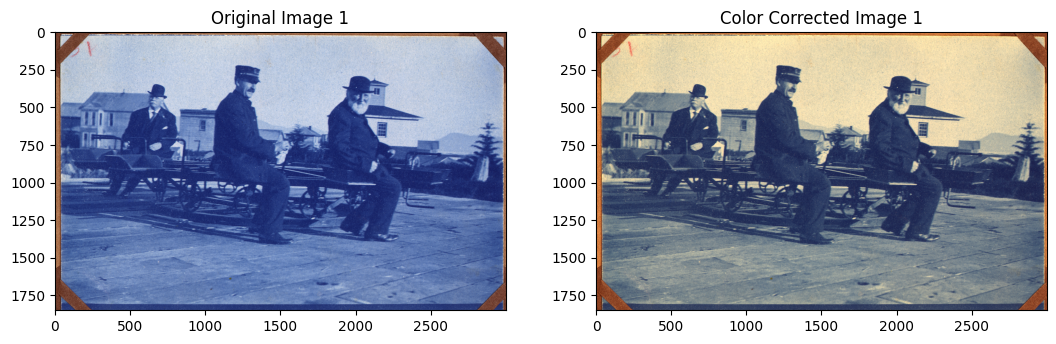

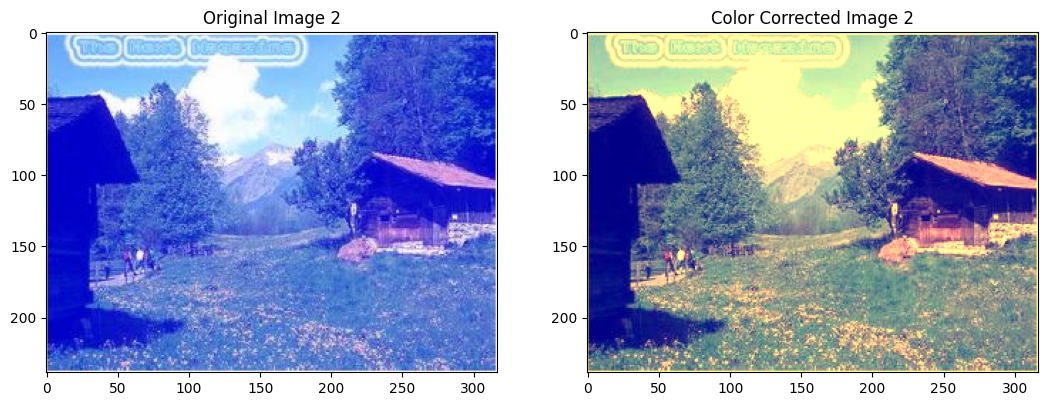

In [8]:
img1 = io.imread('1.jpg')
img2 = io.imread('2.jpg')

corrected1 = color_correction(img1.astype(np.float32))
corrected2 = color_correction(img2.astype(np.float32))



show_images([img1.astype(np.uint8), corrected1], ['Original Image 1', 'Color Corrected Image 1'])
show_images([img2.astype(np.uint8), corrected2], ['Original Image 2', 'Color Corrected Image 2'])
